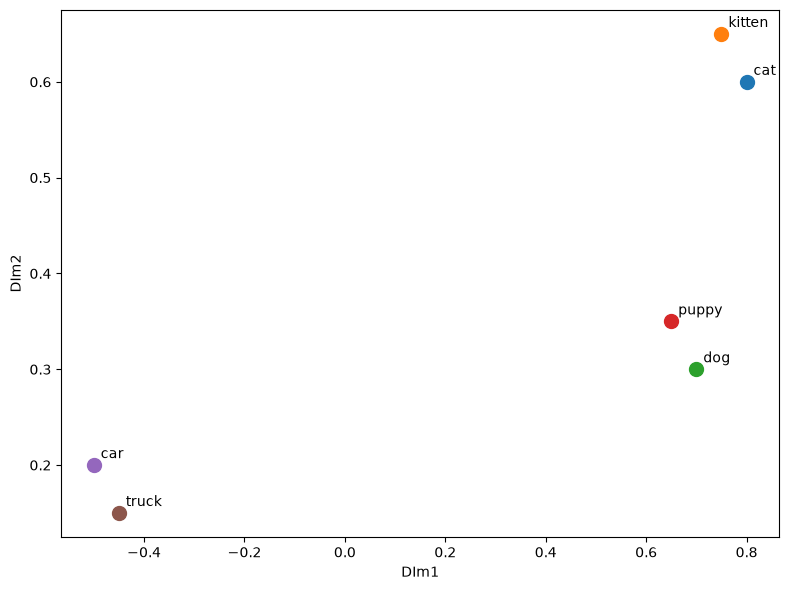

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

word_embeddings={
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "dog":[0.7,0.3],
    "puppy":[0.65,0.35],
    "car":[-0.5,0.2],
    "truck":[-0.45,0.15]
}

fig,ax=plt.subplots(figsize=(8,6))

for word , coord in word_embeddings.items():
    ax.scatter(coord[0],coord[1],s=100)
    ax.annotate(word,(coord[0],coord[1]),xytext=(5,5),textcoords='offset points')

ax.set_xlabel("DIm1")
ax.set_ylabel("DIm2")
plt.tight_layout()
plt.show()

In [2]:
def cosie_sim(vec1,vec2):

    dot_prod=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_prod/(norm_a*norm_b)

cat=[0.8,0.6]
kitten=[0.75,0.65]
dog=[0.7,0.3]

similarity=cosie_sim(cat,kitten)
print(similarity)

sim1=cosie_sim(cat,dog)
print(sim1)


0.9975095892825593
0.971667603161947


## Embeddings

In [1]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

splitter=RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

db=Chroma(
    collection_name="games_ai",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

loader=PyMuPDFLoader(
    "PDFS/Evolution_of_Video_Games_and_AI.pdf"
)
documents=loader.load()
chunks=splitter.split_documents(documents)

ids=[
    f"{chunk.metadata['source']}_{i}"
    for i , chunk in enumerate(chunks)
]

db.add_documents(
    documents=chunks,
    ids=ids
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_4112\928241522.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

['PDFS/Evolution_of_Video_Games_and_AI.pdf_0',
 'PDFS/Evolution_of_Video_Games_and_AI.pdf_1',
 'PDFS/Evolution_of_Video_Games_and_AI.pdf_2',
 'PDFS/Evolution_of_Video_Games_and_AI.pdf_3']

In [2]:
for i in range(4):
    print(ids[i])

PDFS/Evolution_of_Video_Games_and_AI.pdf_0
PDFS/Evolution_of_Video_Games_and_AI.pdf_1
PDFS/Evolution_of_Video_Games_and_AI.pdf_2
PDFS/Evolution_of_Video_Games_and_AI.pdf_3


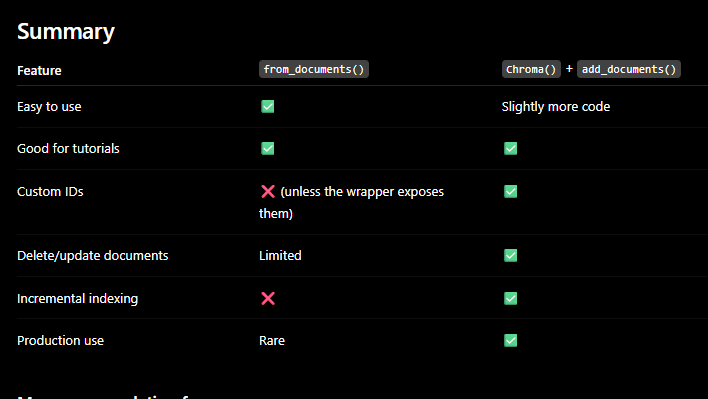

In [7]:
 #db.delete_collection()

## Add New Documents

In [5]:
loader=PyMuPDFLoader(
    "PDFS/Artificial_Intelligence_in_Healthcare.pdf"
)

documents=loader.load()
chunks=splitter.split_documents(documents)

ids=[
    f"{chunk.metadata['source']}_{i}"
    for i , chunk in enumerate(chunks)
]

db.add_documents(
    documents=chunks,
    ids=ids
)

['PDFS/Artificial_Intelligence_in_Healthcare.pdf_0',
 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_1',
 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_2',
 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_3',
 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_4']

In [6]:

data = db.get()

print("Total:", len(data["ids"]))
print(data["ids"])

Total: 9
['PDFS/Evolution_of_Video_Games_and_AI.pdf_0', 'PDFS/Evolution_of_Video_Games_and_AI.pdf_1', 'PDFS/Evolution_of_Video_Games_and_AI.pdf_2', 'PDFS/Evolution_of_Video_Games_and_AI.pdf_3', 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_0', 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_1', 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_2', 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_3', 'PDFS/Artificial_Intelligence_in_Healthcare.pdf_4']


In [10]:
results = db.similarity_search_with_score(
    "How AI is used in health care?",
    k=3
)

for doc, score in results:
    print("Score:", score)
    print("Source:", doc.metadata.get("source"))
    print("Page:", doc.metadata.get("page"))
    print(doc.page_content[:500])
    print("-" * 80)

Score: 0.7364321947097778
Source: PDFS/Artificial_Intelligence_in_Healthcare.pdf
Page: 1
different from their training data. Regulation, clinical validation, privacy, security, auditability, data
governance, and accountability are essential. The most promising future is likely to involve
collaboration in which AI handles specialized computational tasks while trained professionals retain
responsibility for interpretation and patient care.
Conclusion
This topic demonstrates that major technological and social transformations depend on more than
technical capability alone. Reliability,
--------------------------------------------------------------------------------
Score: 0.7374882102012634
Source: PDFS/Artificial_Intelligence_in_Healthcare.pdf
Page: 0
Artificial Intelligence in Healthcare
Informative Overview
Introduction
Artificial intelligence is increasingly becoming a foundational technology in modern healthcare.
Rather than replacing doctors, nurses, researchers, and technicians, AI

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

# -------------------------
# Retriever
# (assumes `db` is already defined earlier in your script)
# -------------------------
retriever = db.as_retriever(
    search_kwargs={"k": 3}
)

# -------------------------
# LLM - LM Studio
# -------------------------
llm = ChatOpenAI(
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio",
    model="google/gemma-4-e2b",
    temperature=0.2,
    streaming=True,
    stream_usage=True,  # ask backend to include usage on the final chunk
)

# -------------------------
# Prompt
# -------------------------
prompt = ChatPromptTemplate.from_template("""
Use ONLY the context to answer the question.

If the answer is not in the context, answer:
I don't know based on the provided documents.

Do not show your reasoning or thinking process. Respond with the final
answer only, wrapped between these markers:
===ANSWER_START===
(your answer here)
===ANSWER_END===

Context:
{context}

Question:
{question}
""")


# -------------------------
# Helpers
# -------------------------
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
)

question = "How ai is used in games give a detailed and a real life example"

# -------------------------
# Stream the response
# Markers are stripped out live (whether the model sends both, one, or
# neither), and the streamed text IS the final answer — nothing is
# reprinted afterward.
# -------------------------
START_MARKER = "===ANSWER_START==="
END_MARKER = "===ANSWER_END==="
MARKERS = [START_MARKER, END_MARKER]
MAX_MARKER_LEN = max(len(m) for m in MARKERS)

print("Question:", question)
print("Answer: ", end="", flush=True)

full_text = ""     # raw text, exactly as emitted (for debugging if needed)
answer = ""        # visible, marker-free text that gets printed
usage = None
hold_buffer = ""   # small tail withheld in case it's the start of a marker

for chunk in rag_chain.stream(question):
    if chunk.content:
        full_text += chunk.content
        hold_buffer += chunk.content

        # Remove any complete marker that has fully arrived
        for marker in MARKERS:
            hold_buffer = hold_buffer.replace(marker, "")

        # Only print text we're sure isn't the start of a marker —
        # keep the last (MAX_MARKER_LEN - 1) chars back just in case
        if len(hold_buffer) > MAX_MARKER_LEN - 1:
            safe_len = len(hold_buffer) - (MAX_MARKER_LEN - 1)
            safe_text = hold_buffer[:safe_len]
            print(safe_text, end="", flush=True)
            answer += safe_text
            hold_buffer = hold_buffer[safe_len:]

    if getattr(chunk, "usage_metadata", None):
        usage = chunk.usage_metadata

# Flush whatever's left in the buffer once streaming is done
for marker in MARKERS:
    hold_buffer = hold_buffer.replace(marker, "")
if hold_buffer:
    print(hold_buffer, end="", flush=True)
    answer += hold_buffer

answer = answer.strip()
print("\n")

# -------------------------
# Token information
# -------------------------
input_tokens = usage.get("input_tokens", 0) if usage else 0
output_tokens = usage.get("output_tokens", 0) if usage else 0
total_tokens = usage.get("total_tokens", 0) if usage else 0

if usage is None:
    print("(Note: backend did not return usage_metadata during streaming — token counts below are 0.)\n")

# -------------------------
# Context window
# -------------------------
CONTEXT_WINDOW = 8192
tokens_left = max(CONTEXT_WINDOW - total_tokens, 0)

# -------------------------
# Progress bar
# -------------------------
bar_width = 40
used_ratio = total_tokens / CONTEXT_WINDOW if CONTEXT_WINDOW else 0
used_blocks = int(bar_width * used_ratio)
bar = "█" * used_blocks + "░" * (bar_width - used_blocks)

print("Token Usage")
print(f"[{bar}]")
print(f"Used : {total_tokens:,} / {CONTEXT_WINDOW:,}")
print(f"Left : {tokens_left:,}")
print(f"Input: {input_tokens:,}")
print(f"Output: {output_tokens:,}")

NameError: name 'db' is not defined

In [1]:
START_MARKER = "===ANSWER_START==="
END_MARKER = "===ANSWER_END==="

MARKERS = [START_MARKER, END_MARKER]
MAX_MARKER_LEN = max(len(m) for m in MARKERS)

# Pretend these are chunks coming from the LLM
chunks = [
    "===ANSWER_START===",
    "AI is used in games ",
    "for many purposes. ",
    "For example, ",
    "NPCs can use AI ",
    "to behave intelligently.",
    "===ANSWER_END==="
]

hold_buffer = ""
answer = ""

print("Answer: ", end="", flush=True)

for chunk in chunks:

    print(f"\n\n[RECEIVED CHUNK]: {repr(chunk)}")

    hold_buffer += chunk

    # Remove complete markers
    for marker in MARKERS:
        hold_buffer = hold_buffer.replace(marker, "")

    # Keep the last characters in case they are part of a marker
    if len(hold_buffer) > MAX_MARKER_LEN - 1:

        safe_len = len(hold_buffer) - (MAX_MARKER_LEN - 1)

        safe_text = hold_buffer[:safe_len]

        print("[PRINTING]:", repr(safe_text))

        answer += safe_text
        hold_buffer = hold_buffer[safe_len:]

print("\n\nRemaining buffer:", repr(hold_buffer))

for marker in MARKERS:
    hold_buffer = hold_buffer.replace(marker, "")

if hold_buffer:
    answer += hold_buffer

print("\nFinal answer:")
print(answer.strip())

Answer: 

[RECEIVED CHUNK]: '===ANSWER_START==='


[RECEIVED CHUNK]: 'AI is used in games '
[PRINTING]: 'AI '


[RECEIVED CHUNK]: 'for many purposes. '
[PRINTING]: 'is used in games fo'


[RECEIVED CHUNK]: 'For example, '
[PRINTING]: 'r many purpos'


[RECEIVED CHUNK]: 'NPCs can use AI '
[PRINTING]: 'es. For example,'


[RECEIVED CHUNK]: 'to behave intelligently.'
[PRINTING]: ' NPCs can use AI to beha'


[RECEIVED CHUNK]: '===ANSWER_END==='


Remaining buffer: 've intelligently.'

Final answer:
AI is used in games for many purposes. For example, NPCs can use AI to behave intelligently.


In [11]:
data = db.get()

print("Total IDs:", len(data["ids"]))
print("Unique IDs:", len(set(data["ids"])))

Total IDs: 9
Unique IDs: 9
